# Season 1 notes

I used this notebook to review the basic tools that show up everywhere in ML work. Then I trained a small KNN model on iris so I could connect the library tour to a real prediction task.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import sparse
from IPython.display import display
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')

## NumPy and sparse matrices

I wanted to remind myself what dense and sparse data look like before jumping into the model. Sparse storage matters once most entries are zero, because I only keep the useful values and coordinates.

In [2]:
x = np.array([[1, 2, 3], [4, 5, 6]])
print('Dense NumPy array:')
print(x)

eye = np.eye(4)
csr_eye = sparse.csr_matrix(eye)
coo_eye = sparse.coo_matrix((np.ones(4), (np.arange(4), np.arange(4))))

print() 
print('Identity matrix:')
print(eye)
print()
print('CSR matrix:')
print(csr_eye)
print()
print('COO matrix:')
print(coo_eye)

Dense NumPy array:
[[1 2 3]
 [4 5 6]]

Identity matrix:
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

CSR matrix:
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0

COO matrix:
<COOrdinate sparse matrix of dtype 'float64'
	with 4 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	1.0
  (1, 1)	1.0
  (2, 2)	1.0
  (3, 3)	1.0


## A quick plotting check

This is just a small sanity check that I still remember the basic plotting flow: make the data, label the axes, and keep the picture readable.

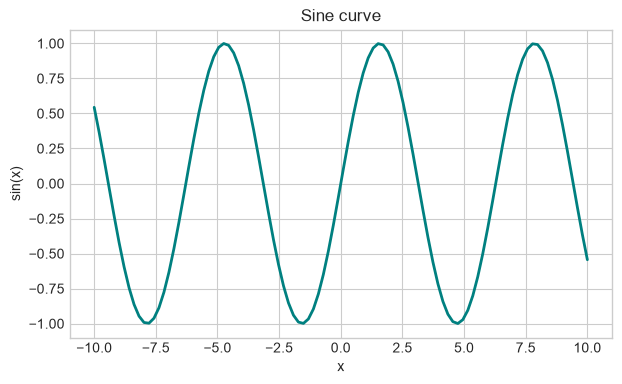

In [3]:
x_plot = np.linspace(-10, 10, 100)
y_plot = np.sin(x_plot)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_plot, y_plot, color='teal', linewidth=2)
ax.set(title='Sine curve', xlabel='x', ylabel='sin(x)')
plt.show()

## A tiny pandas table

I also reviewed simple table filtering, because most ML notebooks start with that kind of quick inspection.

In [4]:
people = pd.DataFrame({
    'Name': ['John', 'Anna', 'Peter', 'Linda'],
    'Location': ['New York', 'Paris', 'Berlin', 'London'],
    'Age': [24, 13, 53, 33]
})

display(people)
print('People older than 30:')
display(people.loc[people['Age'] > 30])

,Name,Location,Age
0,John,New York,24
1,Anna,Paris,13
2,Peter,Berlin,53
3,Linda,London,33


People older than 30:


,Name,Location,Age
2,Peter,Berlin,53
3,Linda,London,33


## Iris dataset first look

The iris dataset is small, but it is still good for checking the full workflow: inspect the data, split it, train a model, and look at the mistakes.

In [5]:
iris = load_iris(as_frame=True)
X = iris.data.copy()
y = iris.target.copy()

print('Feature names:', list(X.columns))
print('Target names:', list(iris.target_names))
print('Data shape:', X.shape)
print('Class counts:')
print(y.value_counts().sort_index())

display(X.head())

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Data shape: (150, 4)
Class counts:
target
0    50
1    50
2    50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Train and test split

I used `stratify=y` so each split keeps the class balance. That matters even for a tiny dataset, because otherwise a small class imbalance could make the score harder to trust.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Train class counts:')
print(y_train.value_counts().sort_index())
print('Test class counts:')
print(y_test.value_counts().sort_index())

X_train shape: (112, 4)
X_test shape: (38, 4)
Train class counts:
target
0    38
1    37
2    37
Name: count, dtype: int64
Test class counts:
target
0    12
1    13
2    13
Name: count, dtype: int64


## Training data view

I only plotted the training set here, so my visual impression comes from the data the model is allowed to learn from.

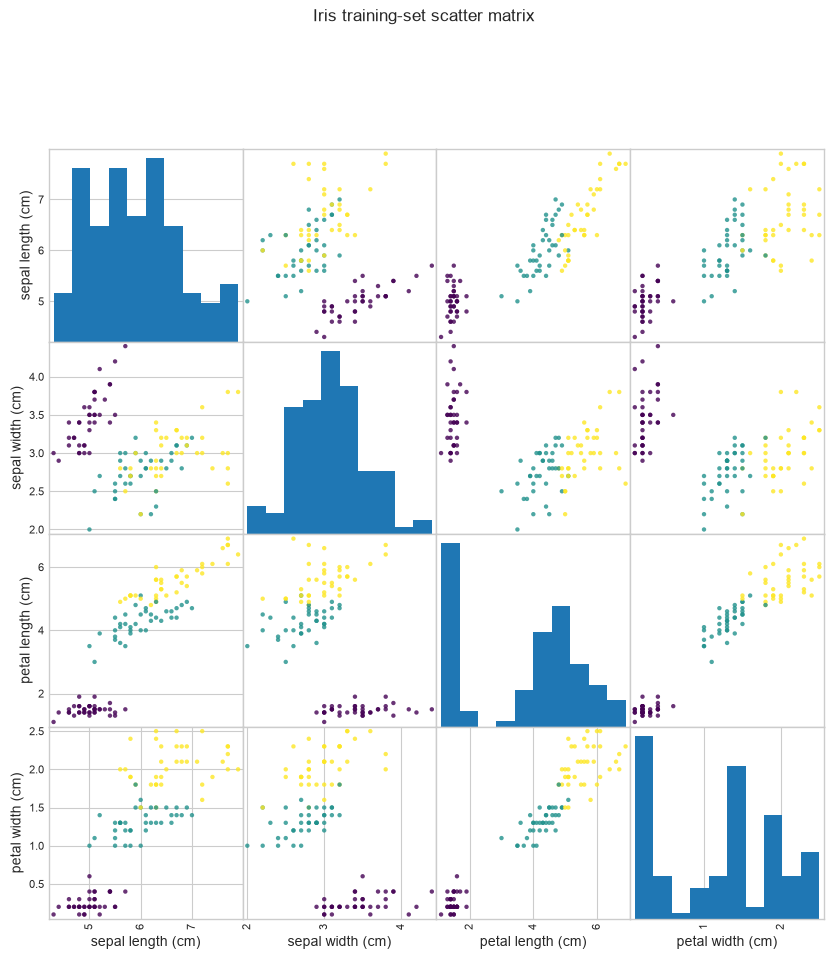

In [7]:
pd.plotting.scatter_matrix(
    X_train,
    c=y_train,
    figsize=(10, 10),
    diagonal='hist',
    alpha=0.8,
    s=40,
    cmap='viridis'
)
plt.suptitle('Iris training-set scatter matrix', y=1.02)
plt.show()

## KNN baseline

I kept the model simple on purpose. A 1-nearest-neighbor classifier makes the distance idea very concrete, even if it can be a bit noisy.

In [8]:
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

new_flower = pd.DataFrame(
    [[5.0, 2.9, 1.0, 0.2]],
    columns=X.columns,
)
prediction = knn.predict(new_flower)[0]

print('Predicted class index:', prediction)
print('Predicted class name:', iris.target_names[prediction])

Predicted class index: 0
Predicted class name: setosa


## Evaluation

Here I checked both the overall accuracy and the confusion matrix. The confusion matrix helps me see whether the model is learning the easy class only or whether the harder classes are also separated well.

In [9]:
y_pred = knn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f'Test accuracy: {accuracy:.3f}')
cm_df = pd.DataFrame(cm, index=iris.target_names, columns=iris.target_names)
display(cm_df)
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Test accuracy: 0.947


,setosa,versicolor,virginica
setosa,12,0,0
versicolor,0,13,0
virginica,0,2,11


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.87      1.00      0.93        13
   virginica       1.00      0.85      0.92        13

    accuracy                           0.95        38
   macro avg       0.96      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



## What I learned

The stratified split stayed nicely balanced, with 38 training rows and 12 to 13 examples from each class in the test set. My 1-NN baseline reached 94.7% accuracy, which is strong for such a small model.

Setosa was separated perfectly, and the only mistakes came from two virginica flowers being predicted as versicolor. That matches the scatter matrix, where those two classes overlap more than setosa.